# Week 3: Risk Metrics and Portfolio Construction

Builds a reusable risk-metrics module (`src/risk.py`), applies it to the Week 2 factor portfolios, then compares portfolio construction methods.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd

sys.path.append("../../src")
from risk import compute_risk_metrics, infer_periods_per_year, max_drawdown
from factor_utils import performance_table

PORTFOLIOS = "../../data/portfolios"
REPORTS = "../../reports/week3"
os.makedirs(REPORTS, exist_ok=True)

## Task 1: Risk Metrics

`compute_risk_metrics()` in `src/risk.py` reports, for any return series:

| Metric | Definition | Basis |
| --- | --- | --- |
| Annual return (CAGR) | compound growth per year | annualized |
| Annual return (mean) | average periodic return × periods per year | annualized |
| Volatility | std of periodic returns × √(periods per year) | annualized |
| Downside deviation | √mean(min(r − rf, 0)²) × √(periods per year) | annualized |
| Sharpe | annual mean excess return ÷ volatility | annualized |
| Sortino | annual mean excess return ÷ downside deviation | annualized |
| Max drawdown | worst fall from a previous peak | over the full period |
| Calmar | CAGR ÷ \|max drawdown\| | annualized |
| Skewness, excess kurtosis | shape of the periodic return distribution | per period (not annualized) |
| Hit rate | share of periods with a positive return | per period |

**Annualization follows the data's frequency:** daily → 252, monthly → 12, inferred from the dates (the function refuses to guess if the spacing is unclear). Risk-free rate = 0 throughout: correct for the zero-cost long–short, and it keeps every row on the same basis.

### 1.1 Load the Week 2 portfolios
Monthly equal-weight quintile returns (Q1–Q5) and the long–short (Q5 − Q1) for value and momentum, July 2021 – August 2026.

In [2]:
value_ret = pd.read_csv(f"{PORTFOLIOS}/value_quintile_returns.csv", index_col=0, parse_dates=True)
mom_ret = pd.read_csv(f"{PORTFOLIOS}/momentum_quintile_returns.csv", index_col=0, parse_dates=True)
COLS = ["Q1", "Q2", "Q3", "Q4", "Q5", "long_short"]

print("Frequency inferred from the dates:", infer_periods_per_year(value_ret.index), "periods per year (monthly)")
print("Months:", len(value_ret), "|", value_ret.index.min().date(), "to", value_ret.index.max().date())

Frequency inferred from the dates: 12 periods per year (monthly)
Months: 62 | 2021-07-30 to 2026-08-31


### 1.2 Annualization check: daily vs monthly
The same portfolio (equal-weight across all 50 stocks) measured on **daily** and on **monthly** returns. If annualization is right, annual return, volatility, Sharpe and drawdown should come out nearly the same. Shape statistics (skewness, kurtosis) are *not* annualized, so they differ by frequency and must always state it.

In [3]:
prices = pd.read_csv("../../data/raw/prices_2020.csv", parse_dates=["date"])
px = prices.pivot(index="date", columns="ticker", values="adj_close").loc["2021-07-01":"2026-08-31"]
ew_daily = px.pct_change().mean(axis=1).dropna().rename("Equal-weight, daily returns")
ew_monthly = (1 + ew_daily).resample("ME").prod().sub(1).rename("Equal-weight, monthly returns")

freq_check = pd.concat([compute_risk_metrics(ew_daily), compute_risk_metrics(ew_monthly)])
freq_check[["periods_per_year", "n_periods", "ann_return_cagr", "ann_volatility", "sharpe",
            "max_drawdown", "calmar", "skewness", "excess_kurtosis"]].round(3)

,periods_per_year,n_periods,ann_return_cagr,ann_volatility,sharpe,max_drawdown,calmar,skewness,excess_kurtosis
"Equal-weight, daily returns",252,1296,0.245,0.196,1.217,-0.288,0.852,0.157,5.686
"Equal-weight, monthly returns",12,62,0.244,0.193,1.237,-0.278,0.878,-0.191,-0.501


**What goes wrong with the wrong factor:** the same monthly returns annualized as if they were daily.

In [4]:
wrong = compute_risk_metrics(ew_monthly, periods_per_year=252)
right = compute_risk_metrics(ew_monthly)
pd.DataFrame({
    "correct (12 per year)": right[["ann_volatility", "sharpe"]].iloc[0],
    "wrong (252 per year)": wrong[["ann_volatility", "sharpe"]].iloc[0],
}).round(2)

,correct (12 per year),wrong (252 per year)
ann_volatility,0.19,0.88
sharpe,1.24,5.67


### 1.3 Risk summary table: Week 2 quintile portfolios and long–short factors
Monthly returns, annualized with 12. Saved to `reports/week3/risk_summary.csv`.

In [5]:
risk_summary = pd.concat({
    "Value": compute_risk_metrics(value_ret[COLS]),
    "Momentum": compute_risk_metrics(mom_ret[COLS]),
})
risk_summary.to_csv(f"{REPORTS}/risk_summary.csv")

pct = ["ann_return_cagr", "ann_return_mean", "ann_volatility", "downside_deviation", "max_drawdown", "hit_rate"]
ratios = ["sharpe", "sortino", "calmar", "skewness", "excess_kurtosis"]
show = risk_summary[pct + ratios].copy()
show[pct] = (show[pct] * 100).round(1)
show[ratios] = show[ratios].round(2)
show.columns = ["CAGR %", "Mean ann. %", "Vol %", "Downside dev %", "Max DD %", "Hit rate %",
                "Sharpe", "Sortino", "Calmar", "Skew", "Excess kurt"]
show

CAGR %  Mean ann. %  Vol %  Downside dev %  Max DD %  \
Value    Q1            20.2         22.4   28.3            16.7     -43.6   
         Q2            15.6         16.8   21.7            12.0     -29.1   
         Q3            14.5         15.1   17.4             9.8     -16.3   
         Q4            27.1         26.7   23.0            10.3     -25.1   
         Q5            45.2         42.0   30.0            12.2     -20.9   
         long_short    17.6         19.6   26.4            13.9     -38.9   
Momentum Q1            30.9         30.8   27.3            13.8     -30.1   
         Q2             5.7          7.7   20.7            13.9     -39.9   
         Q3            16.6         16.9   17.2            10.5     -31.2   
         Q4            17.5         18.0   19.1            10.4     -23.1   
         Q5            52.4         49.4   38.3            14.8     -23.1   
         long_short    11.9         18.6   38.5            23.7     -42.7   

                     Hit rate %  Sharpe  Sortino  Calmar  Skew  Excess kurt  
Value    Q1                64.5    0.79     1.34    0.46  0.03         0.18  
         Q2                54.8    0.78     1.40    0.54  0.18        -0.47  
         Q3                62.9    0.87     1.54    0.89 -0.05        -0.36  
         Q4                59.7    1.16     2.59    1.08  0.63         0.44  
         Q5                62.9    1.40     3.43    2.16  0.83         1.85  
         long_short        56.5    0.74     1.41    0.45  0.63         0.85  
Momentum Q1                66.1    1.13     2.23    1.03  0.36         0.54  
         Q2                53.2    0.37     0.55    0.14 -0.31         0.46  
         Q3                62.9    0.98     1.61    0.53 -0.48         0.02  
         Q4                59.7    0.94     1.73    0.76  0.11        -0.35  
         Q5                56.5    1.29     3.33    2.27  1.26         3.54  
         long_short        54.8    0.48     0.78    0.28  0.23         2.94

### 1.4 Checks
1. **Consistency with Week 2:** Sharpe, volatility, max drawdown and hit rate must match Week 2's `performance_table` exactly (same data, same basis).
2. **Hand calculation:** Sortino and Calmar for the value long–short, recomputed from the raw monthly returns.

In [6]:
w2 = pd.concat({"Value": performance_table(value_ret), "Momentum": performance_table(mom_ret)})
pairs = {"sharpe": "sharpe_ratio", "ann_volatility": "annualized_volatility", "max_drawdown": "max_drawdown", "hit_rate": "hit_rate"}
max_diff = max((risk_summary[a] - w2[b].astype(float)).abs().max() for a, b in pairs.items())
print(f"Largest difference vs Week 2: {max_diff:.1e}")

r = value_ret["long_short"]
downside = np.sqrt((np.minimum(r, 0) ** 2).mean()) * np.sqrt(12)
sortino_hand = r.mean() * 12 / downside
cagr_hand = (1 + r).prod() ** (12 / len(r)) - 1
calmar_hand = cagr_hand / abs(max_drawdown(r))
print(f"Value long-short Sortino: hand {sortino_hand:.4f} | code {risk_summary.loc[('Value', 'long_short'), 'sortino']:.4f}")
print(f"Value long-short Calmar:  hand {calmar_hand:.4f} | code {risk_summary.loc[('Value', 'long_short'), 'calmar']:.4f}")

Largest difference vs Week 2: 0.0e+00
Value long-short Sortino: hand 1.4096 | code 1.4096
Value long-short Calmar:  hand 0.4523 | code 0.4523


### 1.5 Reconciling Sortino and Calmar with Sharpe and drawdown
Sortino and Calmar are read *next to* Sharpe and drawdown, not alone:
- **Sortino ÷ Sharpe = volatility ÷ downside deviation.** Above about 1.4 means losses are a smaller share of the swings than in a symmetric distribution, which usually goes with positive skew.
- **Calmar uses compound growth (CAGR) over the worst drawdown.** The gap between mean and CAGR is the "volatility drag": the more volatile the portfolio, the more the simple average overstates what $1 actually grew at.

In [7]:
ls = risk_summary.xs("long_short", level=1)
recon = pd.DataFrame({
    "Sharpe": ls["sharpe"],
    "Sortino": ls["sortino"],
    "Sortino / Sharpe": ls["sortino"] / ls["sharpe"],
    "Vol %": ls["ann_volatility"] * 100,
    "Downside dev %": ls["downside_deviation"] * 100,
    "Skew": ls["skewness"],
    "Excess kurt": ls["excess_kurtosis"],
    "Mean ann. %": ls["ann_return_mean"] * 100,
    "CAGR %": ls["ann_return_cagr"] * 100,
    "Volatility drag (pp)": (ls["ann_return_mean"] - ls["ann_return_cagr"]) * 100,
    "Max DD %": ls["max_drawdown"] * 100,
    "Calmar": ls["calmar"],
}).round(2)
recon

,Sharpe,Sortino,Sortino / Sharpe,Vol %,Downside dev %,Skew,Excess kurt,Mean ann. %,CAGR %,Volatility drag (pp),Max DD %,Calmar
Value,0.74,1.41,1.90,26.39,13.90,0.63,0.85,19.60,17.58,2.02,-38.86,0.45
Momentum,0.48,0.78,1.62,38.53,23.72,0.23,2.94,18.62,11.93,6.69,-42.66,0.28


### 1.6 Risk metrics: notes

- **Function:** `compute_risk_metrics()` in `src/risk.py` takes a return series or a table of them and returns volatility, Sharpe, Sortino, max drawdown, Calmar, skewness, excess kurtosis and hit rate (plus CAGR, mean return and downside deviation).
- **Consistent basis:** every return and risk figure is annualized with the same factor, taken from the data's frequency (12 for the Week 2 monthly portfolios). Skewness, kurtosis and hit rate are per-period and labeled as such. Risk-free rate = 0 for every row.
- **Annualization verified:** the same equal-weight portfolio measured daily and monthly gives nearly the same CAGR (24.5% vs 24.4%), volatility (19.6% vs 19.3%) and Sharpe (1.22 vs 1.24). Annualizing monthly data with 252 by mistake would show 88% volatility and a Sharpe of 5.7, exactly the error the quality check warns about.
- **Checks:** Sharpe, volatility, drawdown and hit rate match Week 2 exactly; Sortino and Calmar match hand calculations.
- **Value vs momentum (long–short):** value ranks ahead on every risk-adjusted measure: Sharpe 0.74 vs 0.48, Sortino 1.41 vs 0.78, Calmar 0.45 vs 0.28. Sortino and Calmar agree with Sharpe and drawdown, so the ranking is not an artifact of one metric.
- **Momentum's tails:** excess kurtosis of 2.9 (vs 0.9 for value) reflects its sudden crashes (−29% in Jan 2023, −30% in Jul 2026). Its 39% volatility also creates a large volatility drag: an 18.6% mean annual return compounds to only 11.9% a year.
- **Top quintiles (Q5):** the highest Sortino (3.4 and 3.3) and strong positive skew (0.8 and 1.3), driven by a few very large months, mostly in 2026.

## Task 2: Correlation, Beta, and Diversification

Everything in this section uses **one benchmark (SPY)** and **one frequency (monthly, last trading day of each month)**, July 2021 – August 2026, the same window and dates as the Week 2 portfolios.

| Measure | Definition |
| --- | --- |
| Beta | cov(portfolio, SPY) / var(SPY) |
| Alpha (annual) | (mean portfolio − beta × mean SPY) × 12 |
| R² | correlation with SPY, squared: share of the portfolio's swings explained by the market |
| Tracking error | std(portfolio − SPY) × √12 |
| Information ratio | mean(portfolio − SPY) × 12 / tracking error |

### 2.1 Benchmark and monthly returns
SPY is downloaded once and cached in `data/raw/spy_2020.csv`. Its month-end prices are taken on exactly the same dates as the stocks, and `align_to_benchmark()` refuses to run if the portfolio and benchmark frequencies differ.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from risk import benchmark_relative_metrics, align_to_benchmark, diversification_curve
from factor_utils import month_end_prices

SPY_FILE = "../../data/raw/spy_2020.csv"
if os.path.exists(SPY_FILE):
    spy = pd.read_csv(SPY_FILE, parse_dates=["date"])
else:
    import yfinance as yf
    raw = yf.download("SPY", start="2020-01-01", end="2026-09-01", auto_adjust=False, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    spy = raw.reset_index().rename(columns={"Date": "date", "Adj Close": "adj_close"})[["date", "adj_close"]]
    spy["ticker"] = "SPY"
    spy.to_csv(SPY_FILE, index=False)

# month-end prices for the 50 stocks and SPY on the same dates
me = month_end_prices(pd.concat([prices, spy[["date", "ticker", "adj_close"]]]), end="2026-08-31")
monthly = me.pct_change().loc["2021-07-01":"2026-08-31"]
spy_m = monthly.pop("SPY").rename("SPY")
stock_m = monthly                                   # 50 stocks, monthly
ew50_m = stock_m.mean(axis=1).rename("Equal-weight 50")

print("Benchmark frequency:", infer_periods_per_year(spy_m.index), "per year")
print("Portfolio frequency:", infer_periods_per_year(value_ret.index), "per year")
print("Same dates as Week 2 portfolios:", value_ret.index.equals(spy_m.index))
print("Stocks with gaps (pairwise correlation used):", stock_m.columns[stock_m.isna().any()].tolist())

Benchmark frequency: 12 per year
Portfolio frequency: 12 per year
Same dates as Week 2 portfolios: True
Stocks with gaps (pairwise correlation used): ['RKLB']


### 2.2 Stock-level correlation heatmap
Fifteen stocks grouped by sector. Saved to `reports/week3/stock_correlation_heatmap.png`.

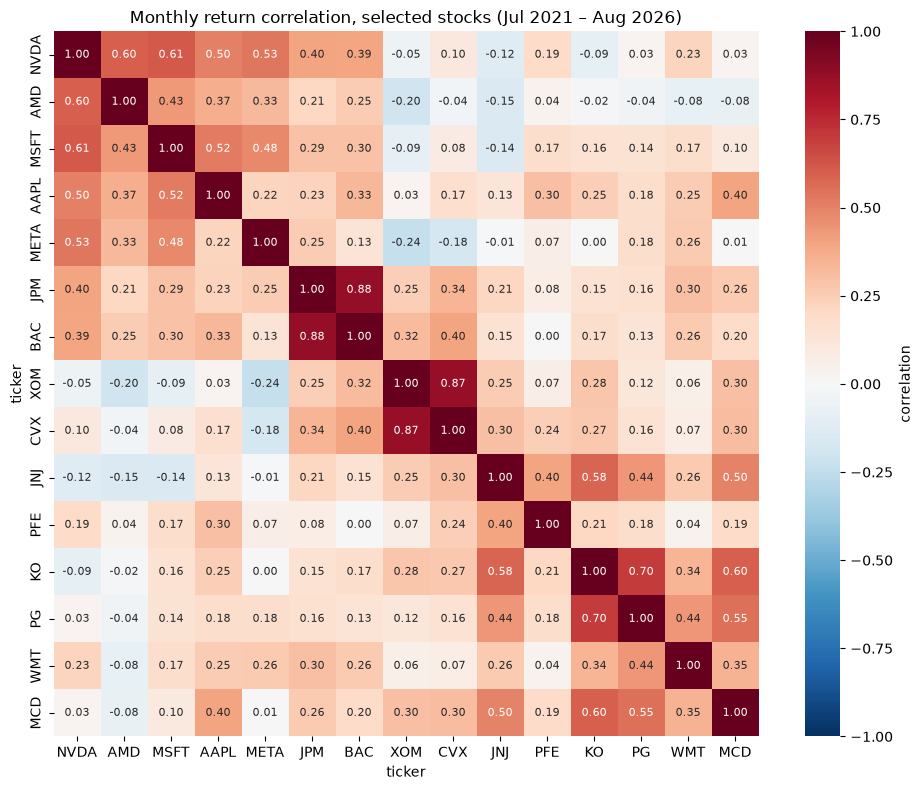

Average pairwise correlation, all 50 stocks: 0.24


In [9]:
SELECTED = ["NVDA", "AMD", "MSFT", "AAPL", "META",     # tech
            "JPM", "BAC",                              # banks
            "XOM", "CVX",                              # energy
            "JNJ", "PFE",                              # healthcare
            "KO", "PG", "WMT", "MCD"]                  # consumer staples / defensive
stock_corr = stock_m[SELECTED].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(stock_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Monthly return correlation, selected stocks (Jul 2021 – Aug 2026)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/stock_correlation_heatmap.png", dpi=150)
plt.show()

all_corr = stock_m.corr().values
n = len(all_corr)
print(f"Average pairwise correlation, all 50 stocks: {(all_corr.sum() - n) / (n * (n - 1)):.2f}")

### 2.3 Portfolio-level correlation matrix
The Week 2 factor portfolios, the equal-weight 50, and SPY. Saved to `reports/week3/portfolio_correlation.csv`.

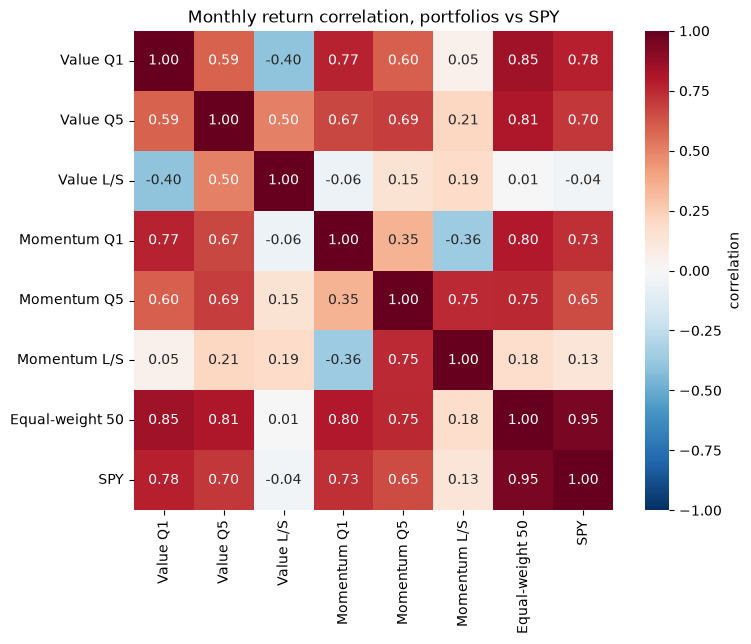

In [10]:
SAMPLE = pd.concat({
    "Value":    value_ret[["Q1", "Q5", "long_short"]],
    "Momentum": mom_ret[["Q1", "Q5", "long_short"]],
}, axis=1)
SAMPLE.columns = [f"{f} {q.replace('long_short', 'L/S')}" for f, q in SAMPLE.columns]
SAMPLE["Equal-weight 50"] = ew50_m

port_corr = SAMPLE.join(spy_m).corr()
port_corr.to_csv(f"{REPORTS}/portfolio_correlation.csv")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(port_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"}, ax=ax)
ax.set_title("Monthly return correlation, portfolios vs SPY")
plt.tight_layout()
plt.savefig(f"{REPORTS}/portfolio_correlation_heatmap.png", dpi=150)
plt.show()

### 2.4 Beta, tracking error and information ratio vs SPY
Same benchmark (SPY), same frequency (monthly), same dates for every portfolio. Saved to `reports/week3/benchmark_relative.csv`.

Tracking error and information ratio measure a long-only portfolio *against* SPY. A long–short is a zero-cost bet, not an alternative to SPY, so for it the useful numbers are beta, alpha and R².

**Flag:** a portfolio with beta of 0.8 or more and R² ≥ 0.5 moves mostly with the market (beta near one or above), however many names it holds. That is *market exposure in disguise*.

In [11]:
rel = benchmark_relative_metrics(SAMPLE, spy_m)
rel["n_stocks"] = [value_ret["n_Q1"].mean(), value_ret["n_Q5"].mean(), np.nan,
                   mom_ret["n_Q1"].mean(), mom_ret["n_Q5"].mean(), np.nan,
                   stock_m.notna().sum(axis=1).mean()]
rel["market_exposure_in_disguise"] = (rel["beta"] >= 0.8) & (rel["r2"] >= 0.5)
rel.to_csv(f"{REPORTS}/benchmark_relative.csv")

show = rel.copy()
for c in ["alpha_ann", "tracking_error", "active_return_ann"]:
    show[c] = (show[c] * 100).round(1)
show = show.rename(columns={"alpha_ann": "alpha_ann %", "tracking_error": "tracking_error %",
                            "active_return_ann": "active_return_ann %"})
show[["beta", "correlation", "r2", "information_ratio"]] = show[["beta", "correlation", "r2", "information_ratio"]].astype(float).round(2)
show["n_stocks"] = show["n_stocks"].round(0)
show.drop(columns=["periods_per_year"])

,beta,alpha_ann %,correlation,r2,tracking_error %,active_return_ann %,information_ratio,n_periods,n_stocks,market_exposure_in_disguise
Value Q1,1.41,2.9,0.78,0.61,18.9,8.5,0.45,62,9.0,True
Value Q5,1.35,23.3,0.70,0.49,22.0,28.1,1.28,62,9.0,False
Value L/S,-0.06,20.4,-0.04,0.00,31.2,5.7,0.18,62,NaN,False
Momentum Q1,1.27,13.1,0.73,0.53,19.2,16.9,0.88,62,10.0,True
Momentum Q5,1.59,27.3,0.65,0.42,30.6,35.5,1.16,62,10.0,False
Momentum L/S,0.32,14.2,0.13,0.02,39.7,4.8,0.12,62,NaN,False
Equal-weight 50,1.20,7.9,0.95,0.90,7.1,10.6,1.50,62,50.0,True


**Check:** beta recomputed by hand as the slope of an ordinary least-squares regression of the value long–short on SPY; and a deliberate frequency mismatch (monthly portfolio vs daily SPY) must be refused.

In [12]:
p = SAMPLE["Value L/S"]
X = np.column_stack([np.ones(len(spy_m)), spy_m.values])
ols_alpha, ols_beta = np.linalg.lstsq(X, p.values, rcond=None)[0]
print(f"Value L/S beta  code {rel.loc['Value L/S', 'beta']:.4f}  vs  OLS {ols_beta:.4f}")
print(f"Value L/S alpha code {rel.loc['Value L/S', 'alpha_ann']:.4f}  vs  OLS {ols_alpha * 12:.4f}")

spy_daily = spy.set_index("date")["adj_close"].pct_change().dropna()
try:
    align_to_benchmark(p, spy_daily)
except ValueError as e:
    print("Frequency mismatch refused:", e)

Value L/S beta  code -0.0613  vs  OLS -0.0613
Value L/S alpha code 0.2045  vs  OLS 0.2045
Frequency mismatch refused: frequency mismatch: portfolio 12/yr vs benchmark 252/yr


### 2.5 Diversification curve
For each portfolio size k, 500 random equal-weight portfolios of k stocks drawn from the stocks with a full history (RKLB is left out because its history starts in August 2021). The line is the average volatility, the band the 10th–90th percentile.

The dashed line is the theory for an equal-weight portfolio of k stocks:

  variance(k) = average variance / k + (1 − 1/k) × average covariance

As k grows the first term vanishes and volatility falls toward **√(average covariance)**, the floor set by how much the stocks move together. Saved to `reports/week3/diversification_curve.png`.

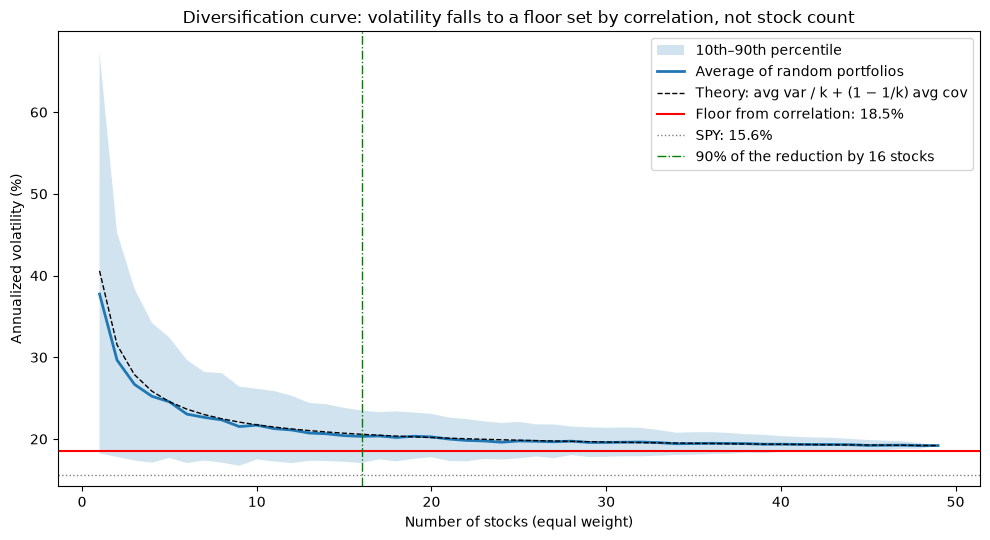

,value
Stocks in the universe,49
Average single-stock volatility,40.6%
Average pairwise correlation,0.24
Floor (√ average covariance),18.5%
"Average volatility, 5 stocks",24.6%
"Average volatility, 10 stocks",21.7%
"Average volatility, 20 stocks",20.3%
"Volatility, all 49 stocks",19.2%
Stocks needed for 90% of the reduction,16


In [13]:
curve = diversification_curve(stock_m, n_draws=500, seed=0)
a = curve.attrs
spy_vol = spy_m.std() * np.sqrt(12)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(curve.index, curve["p10_vol"] * 100, curve["p90_vol"] * 100, alpha=0.2, label="10th–90th percentile")
ax.plot(curve.index, curve["avg_vol"] * 100, lw=2, label="Average of random portfolios")
ax.plot(curve.index, curve["theory_vol"] * 100, "k--", lw=1, label="Theory: avg var / k + (1 − 1/k) avg cov")
ax.axhline(a["floor_vol"] * 100, color="red", lw=1.5, label=f"Floor from correlation: {a['floor_vol']:.1%}")
ax.axhline(spy_vol * 100, color="gray", lw=1, ls=":", label=f"SPY: {spy_vol:.1%}")
ax.axvline(a["n_for_90pct"], color="green", lw=1, ls="-.", label=f"90% of the reduction by {a['n_for_90pct']} stocks")
ax.set_xlabel("Number of stocks (equal weight)")
ax.set_ylabel("Annualized volatility (%)")
ax.set_title("Diversification curve: volatility falls to a floor set by correlation, not stock count")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS}/diversification_curve.png", dpi=150)
plt.show()

pd.DataFrame({
    "Stocks in the universe": a["n_universe"],
    "Average single-stock volatility": f"{a['avg_stock_vol']:.1%}",
    "Average pairwise correlation": f"{a['avg_pairwise_corr']:.2f}",
    "Floor (√ average covariance)": f"{a['floor_vol']:.1%}",
    f"Average volatility, 5 stocks": f"{curve.loc[5, 'avg_vol']:.1%}",
    f"Average volatility, 10 stocks": f"{curve.loc[10, 'avg_vol']:.1%}",
    f"Average volatility, 20 stocks": f"{curve.loc[20, 'avg_vol']:.1%}",
    f"Volatility, all {a['n_universe']} stocks": f"{curve['avg_vol'].iloc[-1]:.1%}",
    "Stocks needed for 90% of the reduction": a["n_for_90pct"],
}, index=["value"]).T

### 2.6 Key findings
Printed from the numbers above.

In [14]:
r = rel
print(f"1. Diversification: volatility falls from {a['avg_stock_vol']:.0%} (one stock) to "
      f"{curve.loc[10, 'avg_vol']:.0%} with 10 and {curve['avg_vol'].iloc[-1]:.0%} with all {a['n_universe']}. "
      f"90% of the fall is done by {a['n_for_90pct']} stocks; after that, an average correlation of "
      f"{a['avg_pairwise_corr']:.2f} holds volatility near the {a['floor_vol']:.0%} floor.")
disguised = r.index[r["market_exposure_in_disguise"]].tolist()
print(f"2. Market exposure in disguise (beta ≥ 0.8, R² ≥ 0.5): {', '.join(disguised) if disguised else 'none'}.")
for name in ["Equal-weight 50", "Value Q5", "Momentum Q5"]:
    print(f"   {name}: beta {r.loc[name, 'beta']:.2f}, R² {r.loc[name, 'r2']:.2f}, "
          f"tracking error {r.loc[name, 'tracking_error']:.1%}, information ratio {r.loc[name, 'information_ratio']:.2f}")
for name in ["Value L/S", "Momentum L/S"]:
    print(f"3. {name}: beta {r.loc[name, 'beta']:.2f}, R² {r.loc[name, 'r2']:.2f}, "
          f"alpha {r.loc[name, 'alpha_ann']:.1%} a year.")
print(f"4. Value L/S vs Momentum L/S correlation: {port_corr.loc['Value L/S', 'Momentum L/S']:.2f}.")

1. Diversification: volatility falls from 41% (one stock) to 22% with 10 and 19% with all 49. 90% of the fall is done by 16 stocks; after that, an average correlation of 0.24 holds volatility near the 18% floor.
2. Market exposure in disguise (beta ≥ 0.8, R² ≥ 0.5): Value Q1, Momentum Q1, Equal-weight 50.
   Equal-weight 50: beta 1.20, R² 0.90, tracking error 7.1%, information ratio 1.50
   Value Q5: beta 1.35, R² 0.49, tracking error 22.0%, information ratio 1.28
   Momentum Q5: beta 1.59, R² 0.42, tracking error 30.6%, information ratio 1.16
3. Value L/S: beta -0.06, R² 0.00, alpha 20.4% a year.
3. Momentum L/S: beta 0.32, R² 0.02, alpha 14.2% a year.
4. Value L/S vs Momentum L/S correlation: 0.19.


### 2.7 Notes
- **Same benchmark, same frequency:** beta, alpha, tracking error and information ratio are all measured against SPY on the same monthly month-end dates; `align_to_benchmark()` raises an error on a frequency mismatch (checked above).
- **Correlation sets the floor:** adding stocks removes the stock-specific part of risk only. The part they share (average covariance) stays, so the curve flattens at the floor however many names are added.
- **Count is not diversification:** a long-only portfolio of 10 or 50 stocks with a beta near one and a high R² is mostly SPY exposure: most of its swings come from the market, not from stock selection.
- **Long–short portfolios:** buying Q5 and selling Q1 cancels much of the market exposure, so beta and R² are the right test; tracking error vs SPY is not meaningful for a zero-cost portfolio.

## Task 3: Portfolio Construction Methods

Three ways to weight the same stocks, judged on the **same universe** and the **same rebalancing schedule**, so the results differ only because of the weights.

| Method | Weight of stock i | Inputs it needs |
| --- | --- | --- |
| Equal weight | 1 / N | none |
| Inverse volatility | proportional to 1 / volatility_i | N volatilities |
| Risk parity | set so every stock adds the same share of portfolio risk | full covariance matrix (volatilities **and** correlations) |

**Setup (identical for all three):**
- **Universe:** the 50 stocks. A stock is eligible once it has a full year (252 days) of daily returns, so PLTR and RKLB join later; every method sees the same eligible list each month.
- **Schedule:** rebalance on the last trading day of each month, June 2021 – July 2026; returns are earned July 2021 – August 2026, the same months as Week 2 and Task 2.
- **Estimates:** volatilities and covariances from the 252 daily returns up to and including the rebalance date only (no look-ahead).
- **Turnover:** weights drift with prices during the month; at each rebalance, turnover = ½ × Σ |new weight − drifted weight| (share of the book traded, one way), annualized × 12.

### 3.1 Run the three backtests
Weights, monthly returns and turnover from `backtest_allocation()` in `src/risk.py`. Returns saved to `reports/week3/allocation_returns.csv`.

In [15]:
from risk import (ALLOCATORS, backtest_allocation, concentration_stats, risk_contributions,
                  risk_parity_weights, inverse_vol_weights)
from factor_utils import LISTING_DATES

# daily returns (RKLB treated as missing before its listing, as in Week 2)
daily_px = prices.pivot(index="date", columns="ticker", values="adj_close")
for tk, d in LISTING_DATES.items():
    daily_px.loc[daily_px.index < pd.Timestamp(d), tk] = np.nan
daily_ret = daily_px.pct_change(fill_method=None)

# month-end stock returns on the same dates as Task 2
stock_me = me.drop(columns="SPY")
monthly_ret = stock_me.pct_change(fill_method=None)
rebalance_dates = stock_me.index[(stock_me.index >= "2021-06-30") & (stock_me.index < "2026-08-31")]

alloc_ret, alloc_w, alloc_to = {}, {}, {}
for m in ALLOCATORS:
    alloc_ret[m], alloc_w[m], alloc_to[m] = backtest_allocation(daily_ret, monthly_ret, m, rebalance_dates)
alloc_ret = pd.DataFrame(alloc_ret)
alloc_ret.to_csv(f"{REPORTS}/allocation_returns.csv")

n_held = pd.DataFrame({m: (w > 0).sum(axis=1) for m, w in alloc_w.items()})
print(f"Rebalances: {len(rebalance_dates)}  ({rebalance_dates[0].date()} to {rebalance_dates[-1].date()})")
print(f"Return months: {len(alloc_ret)}  ({alloc_ret.index[0].date()} to {alloc_ret.index[-1].date()})")
print("Same return dates as Week 2 and SPY:", alloc_ret.index.equals(value_ret.index) and alloc_ret.index.equals(spy_m.index))
print("Same stocks held by all three methods every month:", (n_held.nunique(axis=1) == 1).all())
print(f"Stocks held: {n_held.iloc[0, 0]} at the start, {n_held.iloc[-1, 0]} at the end")

Rebalances: 62  (2021-06-30 to 2026-07-31)
Return months: 62  (2021-07-30 to 2026-08-31)
Same return dates as Week 2 and SPY: True
Same stocks held by all three methods every month: True
Stocks held: 48 at the start, 50 at the end


**Checks** at the latest rebalance date:
1. Inverse-volatility weights × volatility is the same number for every stock.
2. Risk-parity risk contributions are all 1/N.
3. No look-ahead: weights recomputed from data cut off at the rebalance date match the backtest.

In [16]:
t = rebalance_dates[-1]
names = alloc_w["Risk parity"].columns[alloc_w["Risk parity"].loc[t] > 0]
cov_t = daily_ret.loc[:t, names].tail(252).cov() * 252
vol_t = np.sqrt(np.diag(cov_t))

iv = alloc_w["Inverse volatility"].loc[t, names]
rp = alloc_w["Risk parity"].loc[t, names]
print(f"1. Inverse vol: weight x vol ranges {(iv * vol_t).min():.5f} to {(iv * vol_t).max():.5f}")
rc = risk_contributions(rp.values, cov_t.values)
print(f"2. Risk parity: risk contributions range {rc.min():.5f} to {rc.max():.5f} (1/N = {1 / len(names):.5f})")

cut = daily_ret.loc[:t]                                   # nothing after t
cov_cut = cut[names].tail(252).cov() * 252
same = np.allclose(risk_parity_weights(cov_cut), rp) and np.allclose(inverse_vol_weights(cov_cut), iv)
print(f"3. Weights rebuilt from data up to {t.date()} only match the backtest: {same}")

1. Inverse vol: weight x vol ranges 0.00643 to 0.00643
2. Risk parity: risk contributions range 0.02000 to 0.02000 (1/N = 0.02000)
3. Weights rebuilt from data up to 2026-07-31 only match the backtest: True


### 3.2 Weight concentration
Averaged over all 62 rebalance dates. Saved to `reports/week3/allocation_concentration.csv`.
- **Effective N (weights)** = 1 / Σ w²: the number of equal-sized positions with the same concentration. 50 = perfectly even.
- **Effective N (risk)**: the same measure on each stock's share of portfolio risk, i.e. how many stocks really drive the risk.

In [17]:
conc = {}
for m, W in alloc_w.items():
    rows = []
    for t in W.index:
        w = W.loc[t][W.loc[t] > 0]
        cov = daily_ret.loc[:t, w.index].tail(252).cov() * 252
        rows.append(concentration_stats(w, cov))
    conc[m] = pd.DataFrame(rows).mean()
conc = pd.DataFrame(conc).T
conc.to_csv(f"{REPORTS}/allocation_concentration.csv")

show_c = conc.copy()
for c in ["max_weight", "min_weight", "top10_weight"]:
    show_c[c] = (show_c[c] * 100).round(1)
show_c = show_c.rename(columns={"max_weight": "max weight %", "min_weight": "min weight %",
                                "top10_weight": "top-10 weight %", "effective_n": "effective N (weights)",
                                "effective_n_risk": "effective N (risk)", "n_stocks": "stocks held"})
show_c.round(1)

,stocks held,max weight %,min weight %,top-10 weight %,effective N (weights),effective N (risk)
Equal weight,49.7,2.0,2.0,20.1,49.7,36.1
Inverse volatility,49.7,3.8,0.7,31.6,43.5,45.9
Risk parity,49.7,5.6,0.7,39.7,37.4,49.7


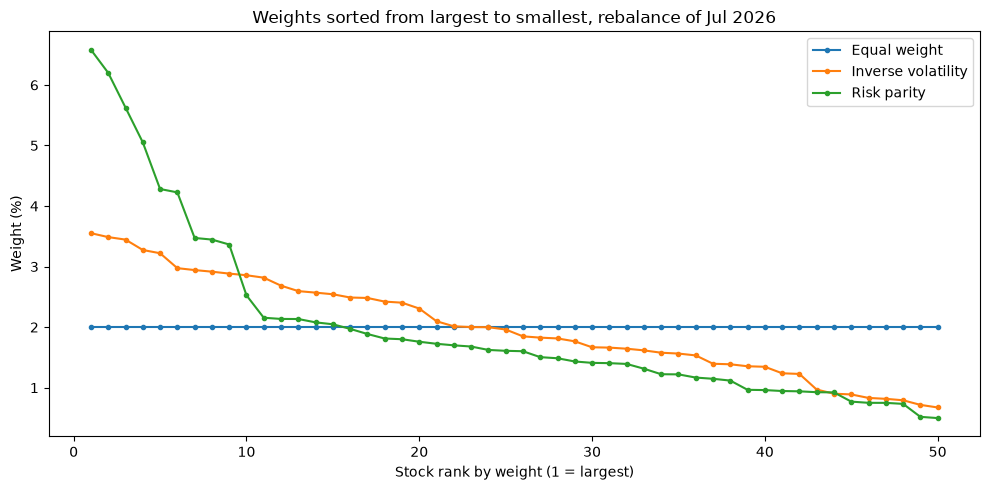

,Equal weight,Inverse volatility,Risk parity
#1,AAPL 2.0%,MCD 3.6%,CVX 6.6%
#2,RKLB 2.0%,JNJ 3.5%,XOM 6.2%
#3,MU 2.0%,KO 3.4%,KO 5.6%
#4,NFLX 2.0%,PG 3.3%,JNJ 5.1%
#5,NKE 2.0%,COST 3.2%,PG 4.3%


In [18]:
t = rebalance_dates[-1]
fig, ax = plt.subplots(figsize=(10, 5))
for m, W in alloc_w.items():
    w = W.loc[t][W.loc[t] > 0].sort_values(ascending=False).values * 100
    ax.plot(range(1, len(w) + 1), w, marker="o", ms=3, label=m)
ax.set_xlabel("Stock rank by weight (1 = largest)")
ax.set_ylabel("Weight (%)")
ax.set_title(f"Weights sorted from largest to smallest, rebalance of {t:%b %Y}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS}/allocation_weights.png", dpi=150)
plt.show()

def top5(w):
    w = w.sort_values(ascending=False).head(5)
    return [f"{tk} {x:.1%}" for tk, x in w.items()]

pd.DataFrame({m: top5(W.loc[t]) for m, W in alloc_w.items()}, index=[f"#{i}" for i in range(1, 6)])

### 3.3 Comparison: return, volatility, Sharpe, drawdown, turnover, beta
Monthly returns, annualized with 12; beta vs SPY on the same dates (the Task 2 benchmark). SPY is shown for reference. Saved to `reports/week3/allocation_comparison.csv`.

In [19]:
rm = compute_risk_metrics(alloc_ret.join(spy_m))
beta = benchmark_relative_metrics(alloc_ret, spy_m)["beta"]
turnover = pd.Series({m: alloc_to[m].mean() * 12 for m in ALLOCATORS})

comparison = pd.DataFrame({
    "CAGR %": rm["ann_return_cagr"] * 100,
    "volatility %": rm["ann_volatility"] * 100,
    "Sharpe": rm["sharpe"],
    "max drawdown %": rm["max_drawdown"] * 100,
    "turnover % / yr": turnover * 100,
    "beta vs SPY": beta,
})
comparison.loc["SPY", "beta vs SPY"] = 1.0
comparison.to_csv(f"{REPORTS}/allocation_comparison.csv")
comparison.round(2)

,CAGR %,volatility %,Sharpe,max drawdown %,turnover % / yr,beta vs SPY
Equal weight,25.17,19.83,1.24,-27.40,42.42,1.20
Inverse volatility,19.05,15.88,1.18,-24.13,38.57,0.99
Risk parity,17.74,15.00,1.17,-21.80,44.21,0.91
SPY,13.43,15.64,0.89,-23.93,NaN,1.00


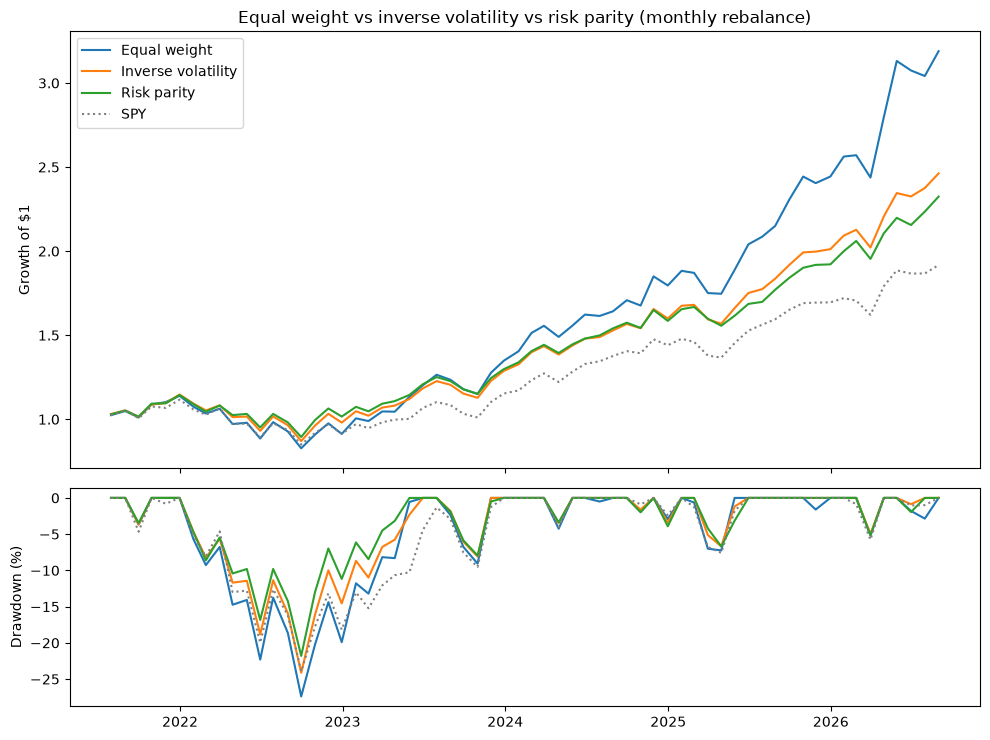

In [20]:
growth = (1 + alloc_ret.join(spy_m)).cumprod()
fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for c in growth.columns:
    style = {"color": "gray", "ls": ":"} if c == "SPY" else {}
    axes[0].plot(growth.index, growth[c], label=c, **style)
    axes[1].plot(growth.index, (growth[c] / growth[c].cummax() - 1) * 100, label=c, **style)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Equal weight vs inverse volatility vs risk parity (monthly rebalance)")
axes[0].legend()
axes[1].set_ylabel("Drawdown (%)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/allocation_growth_drawdown.png", dpi=150)
plt.show()

### 3.4 Key findings
Printed from the numbers above.

In [21]:
c, k = comparison, conc
best_sharpe = c.loc[list(ALLOCATORS), "Sharpe"].idxmax()
print(f"1. Return vs risk: equal weight has the highest CAGR ({c.loc['Equal weight', 'CAGR %']:.1f}%) but also the highest "
      f"volatility ({c.loc['Equal weight', 'volatility %']:.1f}%), drawdown ({c.loc['Equal weight', 'max drawdown %']:.1f}%) "
      f"and beta ({c.loc['Equal weight', 'beta vs SPY']:.2f}). Risk parity is the calmest: volatility "
      f"{c.loc['Risk parity', 'volatility %']:.1f}%, drawdown {c.loc['Risk parity', 'max drawdown %']:.1f}%, beta {c.loc['Risk parity', 'beta vs SPY']:.2f}.")
print(f"2. Best Sharpe: {best_sharpe} ({c.loc[best_sharpe, 'Sharpe']:.2f}); "
      + ", ".join(f"{m} {c.loc[m, 'Sharpe']:.2f}" for m in ALLOCATORS if m != best_sharpe) + ".")
print("3. Turnover per year: " + ", ".join(f"{m} {c.loc[m, 'turnover % / yr']:.0f}%" for m in ALLOCATORS)
      + ". Equal weight trades only to undo price drift; risk parity also trades every time its correlation estimates move.")
print("4. Concentration (average): effective N " + ", ".join(f"{m} {k.loc[m, 'effective_n']:.0f}" for m in ALLOCATORS)
      + "; largest position " + ", ".join(f"{m} {k.loc[m, 'max_weight']:.1%}" for m in ALLOCATORS) + ".")
print("   Effective N of risk: " + ", ".join(f"{m} {k.loc[m, 'effective_n_risk']:.0f}" for m in ALLOCATORS)
      + " -> equal dollars is not equal risk; equal risk needs uneven dollars.")

1. Return vs risk: equal weight has the highest CAGR (25.2%) but also the highest volatility (19.8%), drawdown (-27.4%) and beta (1.20). Risk parity is the calmest: volatility 15.0%, drawdown -21.8%, beta 0.91.
2. Best Sharpe: Equal weight (1.24); Inverse volatility 1.18, Risk parity 1.17.
3. Turnover per year: Equal weight 42%, Inverse volatility 39%, Risk parity 44%. Equal weight trades only to undo price drift; risk parity also trades every time its correlation estimates move.
4. Concentration (average): effective N Equal weight 50, Inverse volatility 43, Risk parity 37; largest position Equal weight 2.0%, Inverse volatility 3.8%, Risk parity 5.6%.
   Effective N of risk: Equal weight 36, Inverse volatility 46, Risk parity 50 -> equal dollars is not equal risk; equal risk needs uneven dollars.


### 3.5 Notes
- **Same universe and schedule:** all three methods hold the same eligible stocks every month, rebalance on the same month-ends, and use only data up to the rebalance date (checked in 3.1).
- **Sharpe alone does not separate them:** Sharpe ratios sit within 0.07 of each other (1.17–1.24). Equal weight's higher return mostly comes with more market exposure (beta 1.20) in a rising market; inverse volatility and risk parity give up return for lower volatility, a smaller drawdown and a beta below one.
- **Turnover:** risk parity trades the most (44% a year) without a better Sharpe, so on this evidence it is not the better method. Inverse volatility trades the least (39%) because it holds less of the volatile names, which drift the most.
- **Concentration and noisy inputs:** each method leans on more estimates than the last. Equal weight uses none, so nothing can be mis-estimated. Inverse volatility uses 50 volatilities, which are estimated fairly reliably; its tilt stays mild (largest position 3.8%) and its weights stable. Risk parity also uses the 1,225 pairwise correlations, which are much noisier; it concentrates more (top 10 = 40% of the book, CVX and XOM over 6% each) and reshuffles whenever those estimates move. The fewer estimates a method relies on, the less concentrated and more robust it stays, which is why equal weight is so hard to beat out of sample (DeMiguel, Garlappi and Uppal, 2009).
- **Equal dollars is not equal risk:** equal weight's effective N of risk is 36, not 50, because the volatile stocks dominate its risk. Risk parity evens out risk (effective N of risk 50) only by making the dollar weights uneven.

## Task 4: Mean-Variance Optimization

`mean_variance_weights()` in `src/risk.py` is a long-only Markowitz optimizer built on `scipy.optimize.minimize` (SLSQP).

| Objective | What it picks |
| --- | --- |
| Minimum variance | the lowest-volatility portfolio (uses the covariance only) |
| Maximum Sharpe | the highest expected return per unit of volatility (uses expected returns **and** covariance) |
| Target return | the lowest-volatility portfolio for a given expected return (traces the frontier) |

**Constraints:** weights sum to 1; long-only (no weight below 0); a maximum weight per stock; optional sector caps (sector map `SECTORS` in `src/risk.py`).

Three constraint sets are compared throughout:
- **Long-only**: weights between 0 and 100%
- **10% cap**: no stock above 10%
- **10% cap + 25% sector cap**: also no sector above 25%

### 4.1 Inputs: expected returns and covariance
Daily returns of all 50 stocks, September 2021 – August 2026 (the longest window where every stock, including RKLB, has data), annualized × 252.

An expected return estimated from 5 years of data has a standard error of about volatility / √5. That uncertainty is the input the optimizer trusts completely.

In [22]:
import functools
from risk import mean_variance_weights, efficient_frontier, bootstrap_weights, SECTORS

est = daily_ret.loc["2021-09-01":"2026-08-31"]
assert est.notna().all().all() and set(est.columns) == set(SECTORS)
mu = est.mean() * 252
cov = est.cov() * 252
vol = np.sqrt(np.diag(cov))
years = len(est) / 252
se_mu = pd.Series(vol / np.sqrt(years), index=mu.index)

inputs = pd.DataFrame({"expected return %": mu * 100, "volatility %": vol * 100,
                       "std. error of expected return %": se_mu * 100}).sort_values("expected return %", ascending=False)
print(f"{len(est)} days ({years:.1f} years), {est.shape[1]} stocks")
print(f"Median standard error of an expected return: {se_mu.median():.1%} a year "
      f"(median expected return itself: {mu.median():.1%})")
inputs.round(1).head(10)

1254 days (5.0 years), 50 stocks
Median standard error of an expected return: 14.3% a year (median expected return itself: 18.8%)


,expected return %,volatility %,std. error of expected return %
ticker,,,
SMCI,85.8,88.8,39.8
RKLB,69.8,81.8,36.7
MU,68.0,56.6,25.4
PLTR,61.2,67.0,30.0
STX,59.6,47.8,21.4
NVDA,59.5,52.0,23.3
WDC,59.1,52.7,23.6
AVGO,52.0,44.3,19.8
AMD,45.2,57.1,25.6


### 4.2 Optimized portfolios under each constraint set
Maximum-Sharpe and minimum-variance weights from the inputs above (risk-free rate 0, as in Task 1).

**Checks:** every portfolio meets its constraints (weights sum to 1, no negatives, caps respected), and the maximum-Sharpe portfolio's Sharpe is at least as high as every point on its frontier.

In [23]:
CONSTRAINTS = {
    "Long-only": {},
    "10% cap": {"max_weight": 0.10},
    "10% cap + 25% sector cap": {"max_weight": 0.10, "sectors": SECTORS, "sector_cap": 0.25},
}
sector_of = pd.Series(SECTORS)

def stats(w):
    ret, v = w @ mu, np.sqrt(w @ cov.values @ w)
    return ret, v, ret / v

opt_w, frontiers, rows = {}, {}, []
for name, kw in CONSTRAINTS.items():
    frontiers[name] = efficient_frontier(mu, cov, n_points=40, **kw)
    for obj, label in [("max_sharpe", "Max Sharpe"), ("min_variance", "Min variance")]:
        w = mean_variance_weights(mu, cov, objective=obj, **kw)
        opt_w[f"{label}, {name}"] = w
        ret, v, sr = stats(w)
        cap_ok = w.max() <= kw.get("max_weight", 1) + 1e-6
        sec_ok = w.groupby(sector_of).sum().max() <= kw.get("sector_cap", 1) + 1e-6
        rows.append({"portfolio": f"{label}, {name}", "exp. return %": ret * 100, "volatility %": v * 100,
                     "Sharpe": sr, "stocks held": int((w > 0).sum()), "max weight %": w.max() * 100,
                     "max sector %": w.groupby(sector_of).sum().max() * 100,
                     "constraints met": abs(w.sum() - 1) < 1e-9 and (w >= 0).all() and cap_ok and sec_ok})
    best_frontier = frontiers[name]["sharpe"].max()
    assert stats(opt_w[f"Max Sharpe, {name}"])[2] >= best_frontier - 1e-4, name

opt_table = pd.DataFrame(rows).set_index("portfolio")
opt_table.round(2)

,exp. return %,volatility %,Sharpe,stocks held,max weight %,max sector %,constraints met
portfolio,,,,,,,
"Max Sharpe, Long-only",31.23,14.92,2.09,13,18.88,25.69,True
"Min variance, Long-only",15.15,11.48,1.32,19,20.63,31.11,True
"Max Sharpe, 10% cap",33.26,16.32,2.04,15,10.00,26.53,True
"Min variance, 10% cap",14.38,11.62,1.24,20,10.00,34.85,True
"Max Sharpe, 10% cap + 25% sector cap",32.76,16.08,2.04,15,10.00,25.00,True
"Min variance, 10% cap + 25% sector cap",14.77,11.76,1.26,23,10.00,25.00,True


### 4.3 Efficient frontier
Expected return vs volatility for the three constraint sets, with the 50 stocks, the equal-weight and risk-parity portfolios, and the optimized portfolios marked. Saved to `reports/week3/efficient_frontier.png`.

These are **in-sample** numbers: the frontier is drawn with the same data used to estimate the inputs, so it shows the best that could have been done *with hindsight*.

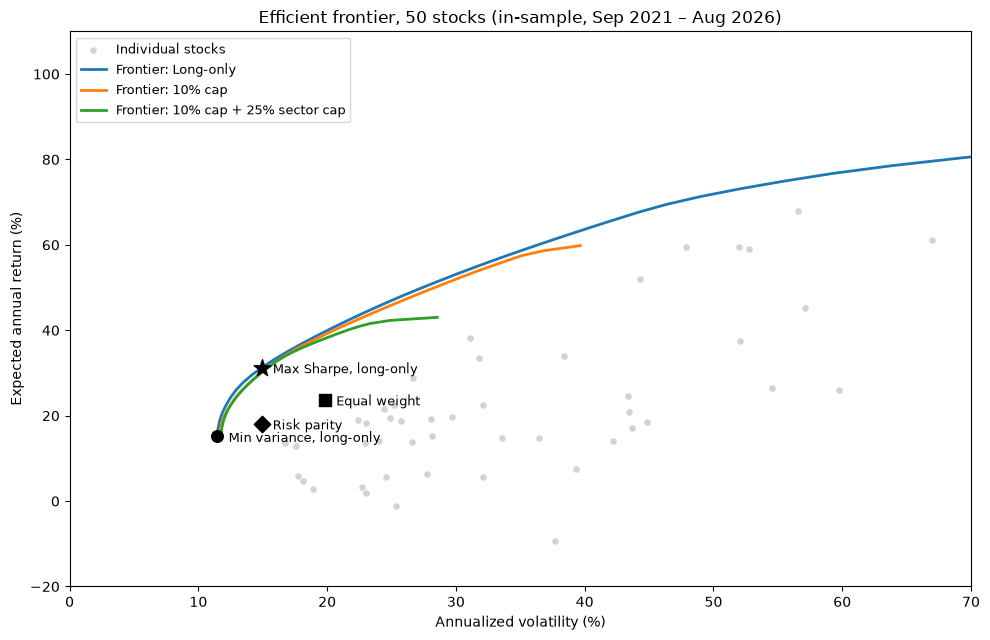

Stocks off the chart area: NKE, RKLB, SMCI


In [24]:
ew_static = pd.Series(1 / len(mu), index=mu.index)
rp_static = risk_parity_weights(cov)

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(vol * 100, mu * 100, s=14, color="lightgray", label="Individual stocks", zorder=1)
for name, fr in frontiers.items():
    ax.plot(fr["volatility"] * 100, fr["exp_return"] * 100, lw=2, label=f"Frontier: {name}", zorder=2)
for label, w, mk in [("Equal weight", ew_static, "s"), ("Risk parity", rp_static, "D"),
                     ("Max Sharpe, long-only", opt_w["Max Sharpe, Long-only"], "*"),
                     ("Min variance, long-only", opt_w["Min variance, Long-only"], "o")]:
    r_, v_, _ = stats(w)
    ax.scatter(v_ * 100, r_ * 100, marker=mk, s=160 if mk == "*" else 70, color="black", zorder=3)
    ax.annotate(label, (v_ * 100, r_ * 100), xytext=(8, -4), textcoords="offset points", fontsize=9)
ax.set_xlim(0, 70)
ax.set_ylim(-20, 110)
ax.set_xlabel("Annualized volatility (%)")
ax.set_ylabel("Expected annual return (%)")
ax.set_title("Efficient frontier, 50 stocks (in-sample, Sep 2021 – Aug 2026)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{REPORTS}/efficient_frontier.png", dpi=150)
plt.show()

off_chart = (vol * 100 > 70) | (mu * 100 > 110) | (mu * 100 < -20)
print("Stocks off the chart area:", ", ".join(mu.index[off_chart]) or "none")

### 4.4 Optimized weights vs equal weight and risk parity
Same inputs for every portfolio. Saved to `reports/week3/optimized_weights.csv`.

In [25]:
compare_w = {"Equal weight": ew_static, "Risk parity": rp_static,
             "Max Sharpe, long-only": opt_w["Max Sharpe, Long-only"],
             "Max Sharpe, 10% cap + sectors": opt_w["Max Sharpe, 10% cap + 25% sector cap"],
             "Min variance, 10% cap": opt_w["Min variance, 10% cap"]}
pd.DataFrame(compare_w).to_csv(f"{REPORTS}/optimized_weights.csv")

conc_w = pd.DataFrame({m: {k: v for k, v in concentration_stats(w[w > 0], cov).items() if k != "min_weight"}
                       for m, w in compare_w.items()}).T
for c in ["max_weight", "top10_weight"]:
    conc_w[c] = conc_w[c] * 100
conc_w.columns = ["stocks held", "max weight %", "top-10 weight %", "effective N (weights)", "effective N (risk)"]
display(conc_w.round(1))

def top5(w):
    w = w.sort_values(ascending=False).head(5)
    return [f"{tk} {x:.1%}" for tk, x in w.items()]
pd.DataFrame({m: top5(w) for m, w in compare_w.items()}, index=[f"#{i}" for i in range(1, 6)])

,stocks held,max weight %,top-10 weight %,effective N (weights),effective N (risk)
Equal weight,50.0,2.0,20.0,50.0,37.2
Risk parity,50.0,5.6,39.2,38.2,50.0
"Max Sharpe, long-only",13.0,18.9,94.2,8.6,10.3
"Max Sharpe, 10% cap + sectors",15.0,10.0,88.3,11.6,11.0
"Min variance, 10% cap",20.0,10.0,77.6,14.0,14.4


,Equal weight,Risk parity,"Max Sharpe, long-only","Max Sharpe, 10% cap + sectors","Min variance, 10% cap"
#1,AAPL 2.0%,JNJ 5.6%,XOM 18.9%,GE 10.0%,PG 10.0%
#2,RKLB 2.0%,KO 4.6%,JNJ 15.5%,WMT 10.0%,MCD 10.0%
#3,MU 2.0%,PG 4.2%,KO 14.9%,MRK 10.0%,KO 10.0%
#4,NFLX 2.0%,PEP 4.1%,MRK 10.2%,JNJ 10.0%,JNJ 10.0%
#5,NKE 2.0%,MRK 3.9%,WMT 9.0%,XOM 10.0%,WMT 8.9%


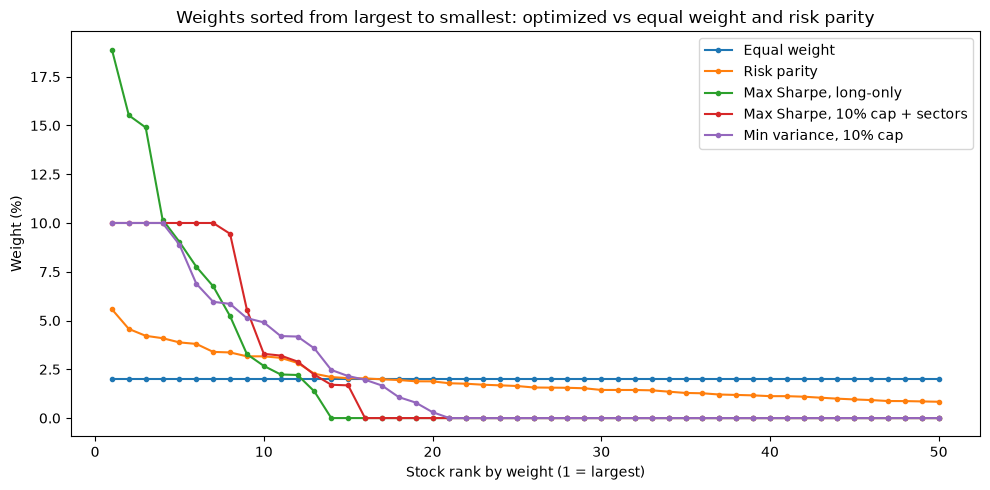

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
for m, w in compare_w.items():
    s = w.sort_values(ascending=False).values * 100
    ax.plot(range(1, len(s) + 1), s, marker="o", ms=3, label=m)
ax.set_xlabel("Stock rank by weight (1 = largest)")
ax.set_ylabel("Weight (%)")
ax.set_title("Weights sorted from largest to smallest: optimized vs equal weight and risk parity")
ax.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS}/optimized_weights.png", dpi=150)
plt.show()

### 4.5 Out of sample: optimized portfolios vs the Task 3 baselines
The in-sample frontier uses hindsight. To compare honestly, the optimizer is run through the **same backtest as Task 3**: same universe, same monthly rebalance, and at each rebalance only the past 252 days are used to estimate expected returns (mean daily return × 252) and covariance. Equal weight and risk parity are the Task 3 results. Saved to `reports/week3/optimized_comparison.csv`.

In [27]:
P = functools.partial
MV_METHODS = {
    "MV max Sharpe, long-only": P(mean_variance_weights, objective="max_sharpe"),
    "MV max Sharpe, 10% cap + sectors": P(mean_variance_weights, objective="max_sharpe",
                                          max_weight=0.10, sectors=SECTORS, sector_cap=0.25),
    "MV min variance, 10% cap": P(mean_variance_weights, objective="min_variance", max_weight=0.10),
}
oos_ret = alloc_ret[["Equal weight", "Risk parity"]].copy()
oos_w = {m: alloc_w[m] for m in ["Equal weight", "Risk parity"]}
oos_to = {m: alloc_to[m] for m in ["Equal weight", "Risk parity"]}
for m, f in MV_METHODS.items():
    oos_ret[m], oos_w[m], oos_to[m] = backtest_allocation(daily_ret, monthly_ret, f, rebalance_dates)
assert oos_ret.index.equals(alloc_ret.index)
oos_ret.to_csv(f"{REPORTS}/optimized_returns.csv")

rm_o = compute_risk_metrics(oos_ret)
beta_o = benchmark_relative_metrics(oos_ret, spy_m)["beta"]
opt_comparison = pd.DataFrame({
    "CAGR %": rm_o["ann_return_cagr"] * 100,
    "volatility %": rm_o["ann_volatility"] * 100,
    "Sharpe": rm_o["sharpe"],
    "max drawdown %": rm_o["max_drawdown"] * 100,
    "turnover % / yr": pd.Series({m: oos_to[m].mean() * 12 * 100 for m in oos_ret}),
    "beta vs SPY": beta_o,
    "avg stocks held": pd.Series({m: (w > 0).sum(axis=1).mean() for m, w in oos_w.items()}),
    "avg max weight %": pd.Series({m: w.max(axis=1).mean() * 100 for m, w in oos_w.items()}),
    "avg effective N": pd.Series({m: (1 / (w ** 2).sum(axis=1)).mean() for m, w in oos_w.items()}),
})
opt_comparison.to_csv(f"{REPORTS}/optimized_comparison.csv")
opt_comparison.round(2)

,CAGR %,volatility %,Sharpe,max drawdown %,turnover % / yr,beta vs SPY,avg stocks held,avg max weight %,avg effective N
Equal weight,25.17,19.83,1.24,-27.40,42.42,1.20,49.73,2.01,49.73
Risk parity,17.74,15.00,1.17,-21.80,44.21,0.91,49.73,5.58,37.45
"MV max Sharpe, long-only",35.96,20.33,1.63,-21.79,321.95,0.94,10.03,33.76,5.65
"MV max Sharpe, 10% cap + sectors",32.76,18.62,1.63,-11.84,247.46,0.92,15.06,10.00,11.95
"MV min variance, 10% cap",11.53,13.01,0.91,-13.29,116.54,0.59,19.87,10.00,12.94


**Is the Sharpe gap real?** A Sharpe ratio measured over 5 years is itself an estimate. Resampling the 62 months (same months for both portfolios, drawn with replacement, 2,000 times) gives the range of the Sharpe difference vs equal weight that this sample can support.

In [28]:
rng = np.random.default_rng(0)
sr = lambda x: x.mean(axis=0) / x.std(axis=0, ddof=1) * np.sqrt(12)
X = oos_ret.values
draws = np.array([sr(X[rng.integers(0, len(X), len(X))]) for _ in range(2000)])
ew_col = list(oos_ret.columns).index("Equal weight")
diff = draws - draws[:, [ew_col]]
sharpe_gap = pd.DataFrame({
    "Sharpe": sr(X),
    "difference vs equal weight": sr(X) - sr(X)[ew_col],
    "90% range: low": np.percentile(diff, 5, axis=0),
    "90% range: high": np.percentile(diff, 95, axis=0),
    "share of draws beating equal weight": (diff > 0).mean(axis=0),
}, index=oos_ret.columns).drop(index="Equal weight")
sharpe_gap.round(2)

,Sharpe,difference vs equal weight,90% range: low,90% range: high,share of draws beating equal weight
Risk parity,1.17,-0.07,-0.29,0.17,0.32
"MV max Sharpe, long-only",1.63,0.39,-0.03,0.81,0.94
"MV max Sharpe, 10% cap + sectors",1.63,0.39,-0.01,0.78,0.95
"MV min variance, 10% cap",0.91,-0.33,-0.95,0.26,0.18


### 4.6 Sensitivity to small input changes
**(a) Small changes to expected returns.** Add a little random noise to every stock's expected return (standard deviation of 1, 2.5 or 5 percentage points, all far below the ~14% standard error from 4.1), re-optimize, and measure how much of the book moves: ½ × Σ |new weight − old weight|. 100 trials per noise level. Equal weight and risk parity do not use expected returns, so this noise moves them by 0%.

In [29]:
rng = np.random.default_rng(0)
nudge_rows = []
for noise in [0.01, 0.025, 0.05]:
    row = {"noise (pp)": noise * 100, "noise / std. error": noise / se_mu.median()}
    for name in ["Long-only", "10% cap + 25% sector cap"]:
        kw = CONSTRAINTS[name]
        base = mean_variance_weights(mu, cov, "max_sharpe", **kw)
        moved = [0.5 * (mean_variance_weights(mu + rng.normal(0, noise, len(mu)), cov, "max_sharpe", **kw)
                        - base).abs().sum() for _ in range(100)]
        row[f"{name}: avg book moved %"] = np.mean(moved) * 100
        row[f"{name}: worst book moved %"] = np.max(moved) * 100
    nudge_rows.append(row)
nudge = pd.DataFrame(nudge_rows).set_index("noise (pp)")
nudge.round(2)

,noise / std. error,Long-only: avg book moved %,Long-only: worst book moved %,10% cap + 25% sector cap: avg book moved %,10% cap + 25% sector cap: worst book moved %
noise (pp),,,,,
1.0,0.07,6.45,13.43,2.38,5.33
2.5,0.17,16.48,37.51,7.02,15.57
5.0,0.35,33.00,58.64,18.18,41.88


**(b) Re-draw the history.** 200 alternative 5-year histories, made by resampling the same daily returns with replacement. Each is statistically just as plausible as the real one. Re-estimate the inputs, re-optimize, and measure how far the weights move from the original. Saved to `reports/week3/weight_sensitivity.png`.

,avg book moved %,worst book moved %,stocks held (min–max),stocks ever held
method,,,,
Equal weight,0.0,0.0,50–50,50
Risk parity,2.1,3.7,50–50,50
"Max Sharpe, long-only",49.1,85.3,6–16,42
"Max Sharpe, 10% cap + sectors",33.8,71.0,12–19,45
"Min variance, 10% cap",10.8,18.7,17–27,41


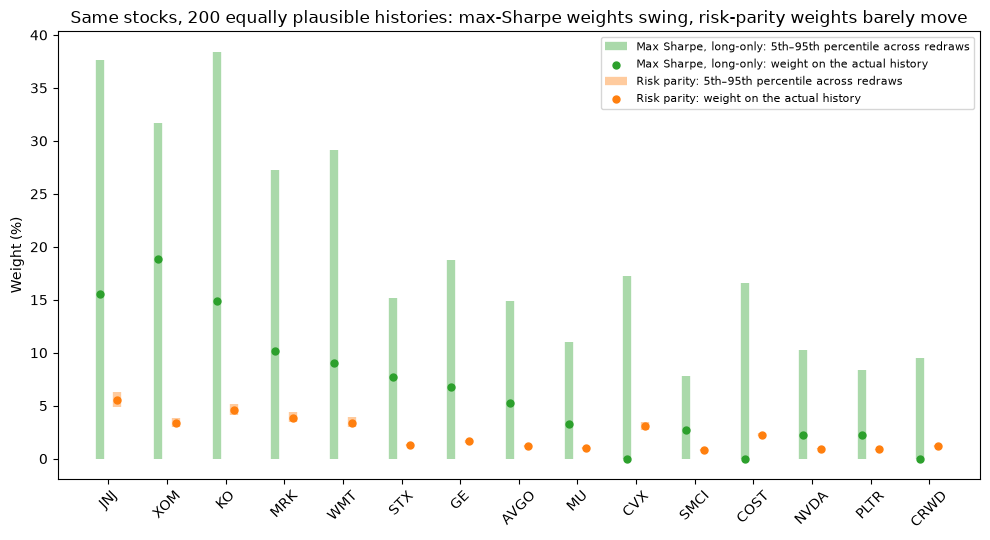

In [30]:
SENS = {
    "Equal weight": lambda cov: pd.Series(1 / len(cov), index=cov.index),
    "Risk parity": risk_parity_weights,
    "Max Sharpe, long-only": P(mean_variance_weights, objective="max_sharpe"),
    "Max Sharpe, 10% cap + sectors": P(mean_variance_weights, objective="max_sharpe",
                                       max_weight=0.10, sectors=SECTORS, sector_cap=0.25),
    "Min variance, 10% cap": P(mean_variance_weights, objective="min_variance", max_weight=0.10),
}
boot, sens_rows = {}, []
for m, f in SENS.items():
    boot[m] = bootstrap_weights(est, f, n_boot=200, seed=0)
    base = compare_w[m]
    moved = 0.5 * (boot[m] - base).abs().sum(axis=1)
    held_ever = (boot[m] > 0).any().sum()
    sens_rows.append({"method": m, "avg book moved %": moved.mean() * 100,
                      "worst book moved %": moved.max() * 100,
                      "stocks held (min–max)": f"{(boot[m] > 0).sum(axis=1).min()}–{(boot[m] > 0).sum(axis=1).max()}",
                      "stocks ever held": held_ever})
sensitivity = pd.DataFrame(sens_rows).set_index("method")
display(sensitivity.round(1))

# weight ranges for the long-only max-Sharpe portfolio vs risk parity
ms = "Max Sharpe, long-only"
top = boot[ms].mean().sort_values(ascending=False).head(15).index
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(top))
for off, m in [(-0.15, ms), (0.15, "Risk parity")]:
    lo, hi = boot[m][top].quantile(0.05) * 100, boot[m][top].quantile(0.95) * 100
    ax.vlines(x + off, lo, hi, lw=6, alpha=0.4, color="C2" if m == ms else "C1",
              label=f"{m}: 5th–95th percentile across redraws")
    ax.scatter(x + off, compare_w[m][top] * 100, color="C2" if m == ms else "C1", zorder=3, s=25,
               label=f"{m}: weight on the actual history")
ax.set_xticks(x)
ax.set_xticklabels(top, rotation=45)
ax.set_ylabel("Weight (%)")
ax.set_title("Same stocks, 200 equally plausible histories: max-Sharpe weights swing, risk-parity weights barely move")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{REPORTS}/weight_sensitivity.png", dpi=150)
plt.show()

### 4.7 Key findings
Printed from the numbers above.

In [31]:
o, g, s = opt_comparison, sharpe_gap, sensitivity
ins = opt_table["Sharpe"]
print(f"1. In sample, the optimizer looks far better: max-Sharpe Sharpe {ins['Max Sharpe, Long-only']:.2f} vs "
      f"{stats(ew_static)[2]:.2f} for equal weight and {stats(rp_static)[2]:.2f} for risk parity, using hindsight inputs.")
print(f"2. Out of sample the gap shrinks: max-Sharpe (long-only) Sharpe {o.loc['MV max Sharpe, long-only', 'Sharpe']:.2f}, "
      f"capped {o.loc['MV max Sharpe, 10% cap + sectors', 'Sharpe']:.2f}, min variance {o.loc['MV min variance, 10% cap', 'Sharpe']:.2f}, "
      f"vs equal weight {o.loc['Equal weight', 'Sharpe']:.2f} and risk parity {o.loc['Risk parity', 'Sharpe']:.2f}.")
for m in ["MV max Sharpe, long-only", "MV max Sharpe, 10% cap + sectors"]:
    print(f"   {m}: Sharpe gap vs equal weight {g.loc[m, 'difference vs equal weight']:+.2f}, 90% range "
          f"{g.loc[m, '90% range: low']:+.2f} to {g.loc[m, '90% range: high']:+.2f}.")
print(f"3. Cost of the optimizer: turnover {o.loc['MV max Sharpe, long-only', 'turnover % / yr']:.0f}% a year (long-only max Sharpe) "
      f"vs {o.loc['Equal weight', 'turnover % / yr']:.0f}% for equal weight; it holds ~{o.loc['MV max Sharpe, long-only', 'avg stocks held']:.0f} "
      f"stocks with an effective N of {o.loc['MV max Sharpe, long-only', 'avg effective N']:.1f}, vs 50 for equal weight.")
print(f"4. Sensitivity: noise of just 1 / 2.5 / 5 points on expected returns moves "
      + " / ".join(f"{x:.0f}%" for x in nudge["Long-only: avg book moved %"]) + " of the max-Sharpe book on average. "
      f"Across redrawn histories the long-only max-Sharpe book moves {s.loc['Max Sharpe, long-only', 'avg book moved %']:.0f}% on average, "
      f"vs {s.loc['Risk parity', 'avg book moved %']:.0f}% for risk parity and 0% for equal weight.")

1. In sample, the optimizer looks far better: max-Sharpe Sharpe 2.09 vs 1.19 for equal weight and 1.21 for risk parity, using hindsight inputs.
2. Out of sample the gap shrinks: max-Sharpe (long-only) Sharpe 1.63, capped 1.63, min variance 0.91, vs equal weight 1.24 and risk parity 1.17.
   MV max Sharpe, long-only: Sharpe gap vs equal weight +0.39, 90% range -0.03 to +0.81.
   MV max Sharpe, 10% cap + sectors: Sharpe gap vs equal weight +0.39, 90% range -0.01 to +0.78.
3. Cost of the optimizer: turnover 322% a year (long-only max Sharpe) vs 42% for equal weight; it holds ~10 stocks with an effective N of 5.6, vs 50 for equal weight.
4. Sensitivity: noise of just 1 / 2.5 / 5 points on expected returns moves 6% / 16% / 33% of the max-Sharpe book on average. Across redrawn histories the long-only max-Sharpe book moves 49% on average, vs 2% for risk parity and 0% for equal weight.


### 4.8 Notes
- **Optimizer and constraints:** `mean_variance_weights()` solves long-only mean-variance problems with `scipy.optimize.minimize` (SLSQP), with a maximum weight per stock and optional sector caps; every solution was checked against its constraints, and the max-Sharpe solution against its frontier.
- **The frontier is hindsight:** in sample the max-Sharpe portfolio reaches a Sharpe of 2.09, against about 1.2 for equal weight and risk parity, because it is built from the same data it is scored on.
- **Out of sample, the optimizer won in this period, but not convincingly:** with inputs from the past year only, max-Sharpe had a Sharpe of 1.63 vs 1.24 for equal weight. Trailing one-year returns act like a momentum signal, and momentum paid in 2021–2026 (Week 2). The resampled 90% range of the gap still includes zero, so 5 years cannot separate skill from luck, and it came with 6–8 times the turnover (247–322% a year vs 42%) and an effective N of 6–12 stocks instead of 50.
- **Minimum variance did worst on return** (Sharpe 0.91): it piled into low-volatility staples and healthcare (beta 0.59) and missed the rally in tech.
- **Small input changes, large weight changes:** noise on expected returns far smaller than their real uncertainty moves a large share of the max-Sharpe book, and re-drawing the same history moves about half of it on average; risk parity moves 2% and equal weight 0%.
- **Why extreme weights are a warning sign:** the optimizer treats every estimate as exact, so it piles into whichever stocks look best by chance in the sample (error maximization). Concentrated, unstable weights are the symptom: they show the optimizer is fitting noise, not finding an edge. The 10% and sector caps limit the damage but do not remove it.
- **Honest benchmark:** equal weight uses no estimates and risk parity uses only the covariance, which is estimated far more reliably than expected returns. Any optimized portfolio has to beat them after turnover, and by more than the sampling noise, before it counts as better.